In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from skimage.feature import local_binary_pattern
from skimage import color
import joblib
import os
from tqdm import tqdm
import warnings
import zipfile
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Extract dataset
ZIP_PATH = '/content/drive/MyDrive/content/KneeXrayData.zip'
EXTRACT_PATH = '/content/KneeXrayData/'

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("✓ Dataset extracted!")

# Define data paths
TRAIN_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/train/'
TEST_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/test/'

# Define LBP feature extraction function
def extract_lbp_features(image_path, num_points=24, radius=3):
    """Extract Local Binary Pattern features"""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, num_points, radius, method='uniform')
    (hist, _) = np.histogram(lbp.ravel(),
                             bins=np.arange(0, num_points + 3),
                             range=(0, num_points + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

# Test
train_grade0_path = os.path.join(TRAIN_PATH, '0')
available_images = os.listdir(train_grade0_path)
test_img = os.path.join(train_grade0_path, available_images[0])
features = extract_lbp_features(test_img)

print(f"\n✓ Setup Complete!")
print(f"Feature vector length: {len(features)}")
print(f"Sample features: {features[:5]}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting dataset...
✓ Dataset extracted!

✓ Setup Complete!
Feature vector length: 26
Sample features: [0.04075654 0.02634726 0.01981027 0.01165896 0.00882892]


In [7]:
def load_dataset_features(data_path, max_samples_per_class=None):
    """
    Load images and extract LBP features for all classes
    """
    X = []
    y = []

    print(f"Extracting features from: {data_path}")

    # For each KL grade (0-4)
    for grade in range(5):
        grade_path = os.path.join(data_path, str(grade))
        image_files = os.listdir(grade_path)

        # Limit samples if specified (for faster testing)
        if max_samples_per_class:
            image_files = image_files[:max_samples_per_class]

        print(f"Processing KL Grade {grade}: {len(image_files)} images...")

        for img_file in tqdm(image_files, desc=f"Grade {grade}"):
            img_path = os.path.join(grade_path, img_file)
            try:
                features = extract_lbp_features(img_path)
                X.append(features)
                y.append(grade)
            except Exception as e:
                print(f"Error processing {img_file}: {e}")
                continue

    return np.array(X), np.array(y)

# Extract features from training set (using subset for speed - 200 per class)
print("=" * 60)
print("EXTRACTING TRAINING FEATURES")
print("=" * 60)
X_train, y_train = load_dataset_features(TRAIN_PATH, max_samples_per_class=200)

print(f"\n✓ Training features extracted!")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


EXTRACTING TRAINING FEATURES
Extracting features from: /content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/train/
Processing KL Grade 0: 200 images...


Grade 0: 100%|██████████| 200/200 [00:06<00:00, 29.23it/s]


Processing KL Grade 1: 200 images...


Grade 1: 100%|██████████| 200/200 [00:06<00:00, 30.81it/s]


Processing KL Grade 2: 200 images...


...

Processing KL Grade 3: 200 images...


Grade 3: 100%|██████████| 200/200 [00:05<00:00, 34.91it/s]


Processing KL Grade 4: 173 images...


Grade 4: 100%|██████████| 173/173 [00:06<00:00, 27.88it/s]


✓ Training features extracted!
X_train shape: (973, 26)
y_train shape: (973,)


In [8]:
# Extract features from test set
print("=" * 60)
print("EXTRACTING TEST FEATURES")
print("=" * 60)
X_test, y_test = load_dataset_features(TEST_PATH, max_samples_per_class=None)

print(f"\n✓ Test features extracted!")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n" + "=" * 60)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 60)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest...")
rf_classifier.fit(X_train, y_train)

print("\n✓ Random Forest trained successfully!")

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")



EXTRACTING TEST FEATURES
Extracting features from: /content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/test/
Processing KL Grade 0: 639 images...


Grade 0: 100%|██████████| 639/639 [00:27<00:00, 23.23it/s]


Processing KL Grade 1: 296 images...


Grade 1: 100%|██████████| 296/296 [00:09<00:00, 30.39it/s]


Processing KL Grade 2: 447 images...


...

Grade 4: 100%|██████████| 51/51 [00:02<00:00, 23.57it/s]
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.



✓ Test features extracted!
X_test shape: (1656, 26)
y_test shape: (1656,)

TRAINING RANDOM FOREST CLASSIFIER
Training Random Forest...


[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s



✓ Random Forest trained successfully!

EVALUATION RESULTS
Accuracy: 0.2512
Macro-F1: 0.2137


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


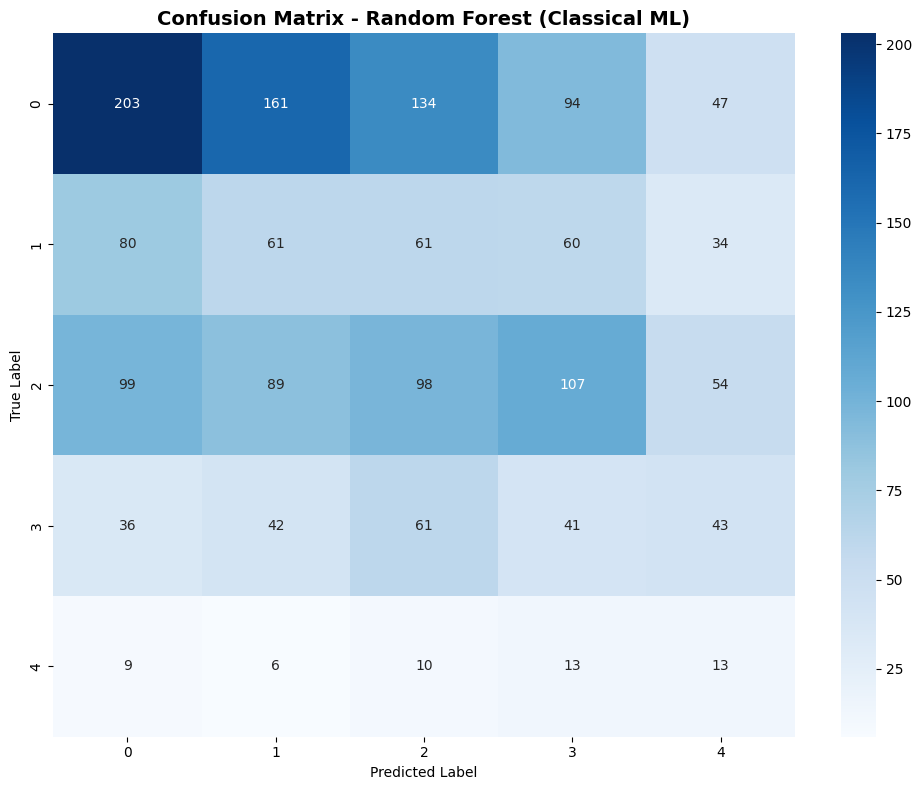

✓ Confusion matrix saved!

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Grade 0       0.48      0.32      0.38       639
     Grade 1       0.17      0.21      0.19       296
     Grade 2       0.27      0.22      0.24       447
     Grade 3       0.13      0.18      0.15       223
     Grade 4       0.07      0.25      0.11        51

    accuracy                           0.25      1656
   macro avg       0.22      0.24      0.21      1656
weighted avg       0.31      0.25      0.27      1656


PER-CLASS ANALYSIS
KL Grade 0: Accuracy = 0.3177 (203/639 correct)
KL Grade 1: Accuracy = 0.2061 (61/296 correct)
KL Grade 2: Accuracy = 0.2192 (98/447 correct)
KL Grade 3: Accuracy = 0.1839 (41/223 correct)
KL Grade 4: Accuracy = 0.2549 (13/51 correct)


In [9]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3, 4],
            yticklabels=[0, 1, 2, 3, 4])
plt.title('Confusion Matrix - Random Forest (Classical ML)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('classical_ml_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved!")

# Print detailed classification report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred,
                           target_names=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']))

# Per-class accuracy analysis
print("\n" + "=" * 60)
print("PER-CLASS ANALYSIS")
print("=" * 60)
for i in range(5):
    class_mask = (y_test == i)
    class_accuracy = accuracy_score(y_test[class_mask], y_pred[class_mask])
    print(f"KL Grade {i}: Accuracy = {class_accuracy:.4f} ({cm[i][i]}/{class_mask.sum()} correct)")
